In [17]:
import networkx as nx
from neo4j_to_networkx import Neo4jToNetworkx
from dotenv import load_dotenv
import os
from neo4j import GraphDatabase
import matplotlib.pyplot as plt
import numpy as np
import json

load_dotenv()

driver = GraphDatabase.driver(
    os.getenv("NEO4J_DSN"),
    auth=(os.getenv("NEO4J_USER"), os.getenv("NEO4J_PASSWORD")),
)

In [29]:
def visualize_concept(concept_graph: nx.Graph):
    # Extract node positions from the graph
    pos = {}
    for node_id, node_data in concept_graph.nodes(data=True):
        # For regular points
        if 'x' in node_data and 'y' in node_data:
            x = json.loads(node_data['x'])['center']
            y = json.loads(node_data['y'])['center']
                
            pos[node_id] = (x, y)
            
        if 'labels' in node_data and 'Vector' in node_data['labels']:
                x1 = json.loads(node_data['x1'])
                x2 = json.loads(node_data['x2'])
                y1 = json.loads(node_data['y1'])
                y2 = json.loads(node_data['y2'])
                
                x1 = x1['center'] if isinstance(x1, dict) and 'center' in x1 else x1
                x2 = x2['center'] if isinstance(x2, dict) and 'center' in x2 else x2
                y1 = y1['center'] if isinstance(y1, dict) and 'center' in y1 else y1
                y2 = y2['center'] if isinstance(y2, dict) and 'center' in y2 else y2
                
                pos[node_id] = (x1, y1)
    
    # Create figure
    plt.figure(figsize=(12, 10))
    
    # Draw nodes with different colors based on labels
    node_colors = []
    for _, data in concept_graph.nodes(data=True):
        if 'labels' in data:
            if 'StartPoint' in data['labels']:
                node_colors.append('green')
            elif 'CornerPoint' in data['labels']:
                node_colors.append('red')
            elif 'Vector' in data['labels']:
                node_colors.append('blue')
            else:
                node_colors.append('gray')
        else:
            node_colors.append('gray')
    
    # Draw the graph
    nx.draw_networkx(
        concept_graph,
        pos=pos,
        with_labels=True,
        node_size=100,
        node_color=node_colors,
        edge_color='black',
        width=1.0,
        alpha=0.8
    )
    
    # Add a legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='StartPoint'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='CornerPoint'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Vector'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Other'),
        plt.Line2D([0], [0], color='blue', lw=2, label='Vector Direction')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.title('Concept Graph Visualization')
    plt.axis('equal')  # Equal aspect ratio
    plt.grid(True)
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
    plt.tight_layout()
    
    return plt.gcf()  # Return the figure for further customization if needed

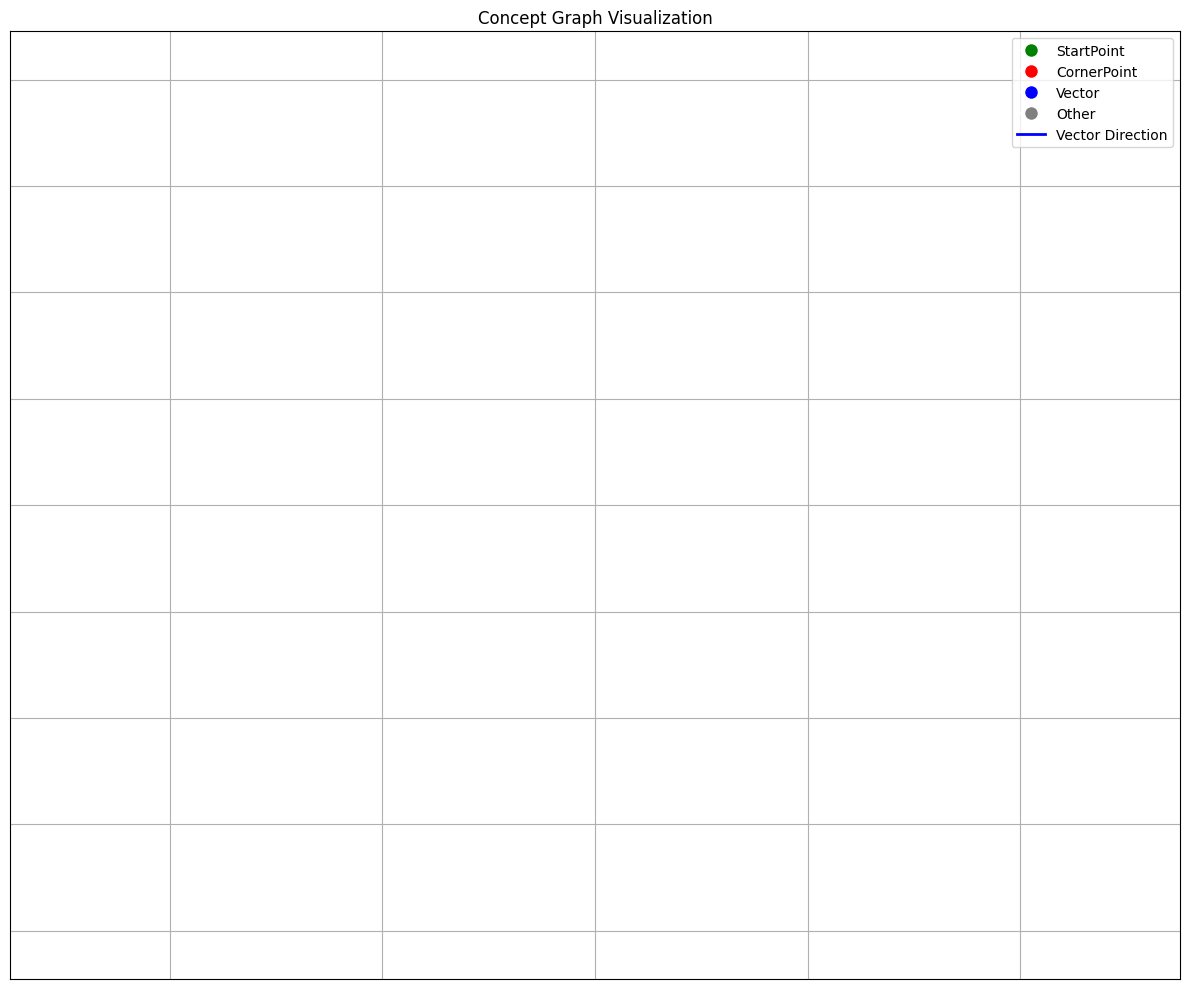

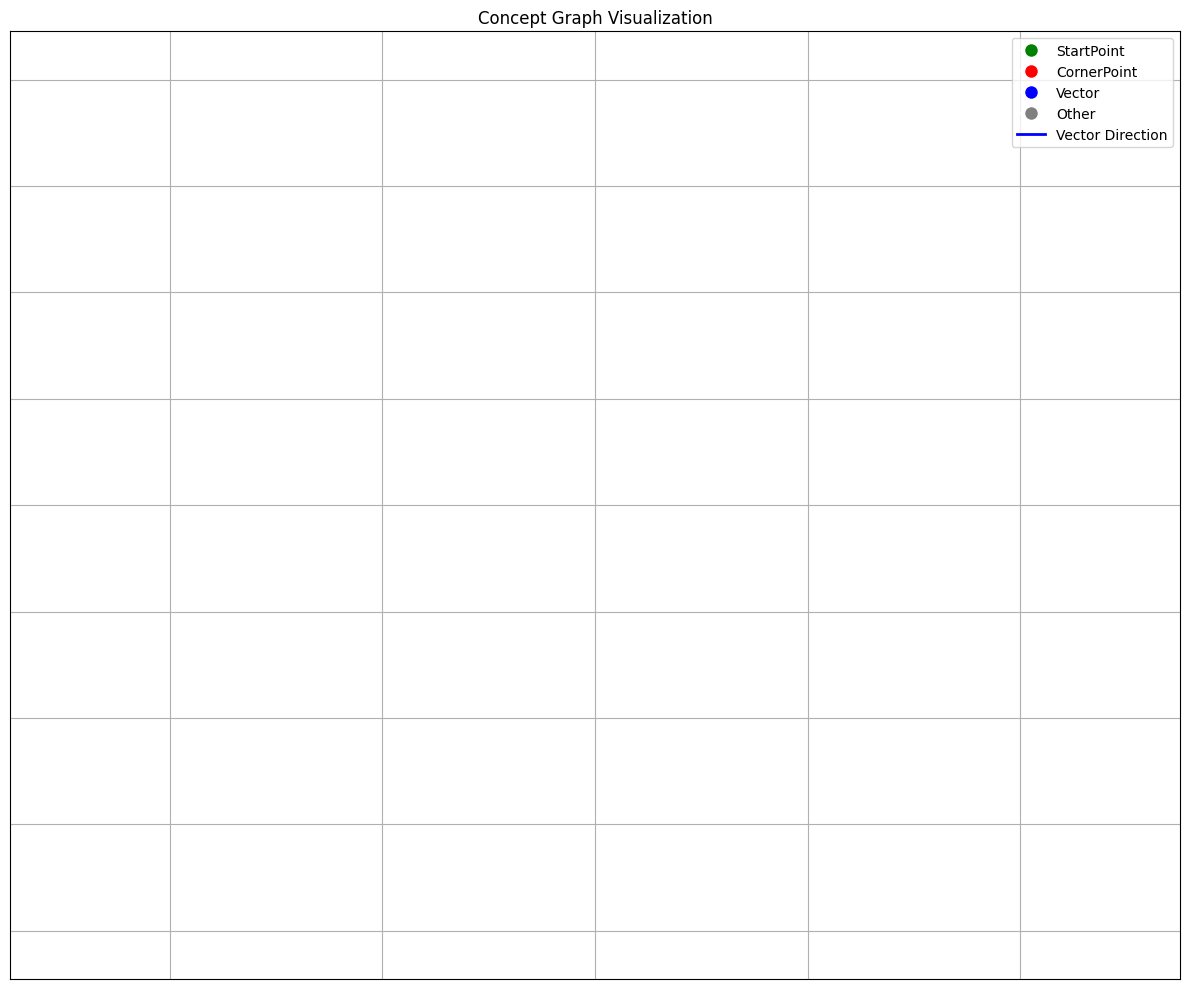

In [30]:
concept_id = '1_1'

with driver.session() as session:
    concept_graph = Neo4jToNetworkx.extract_concept_graph(session, concept_id)
    
visualize_concept(concept_graph)